# Анализ результатов A/B-тестирования интернет-магазина BitMotion Kit

**Информация о заказчике**: интернет-магазин BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

**Задача** — провести оценку результатов A/B-теста. В распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

**Параметры теста**:
- название теста: `interface_eu_test`;
- группы: А (контрольная), B (новый интерфейс).
- базовый показатель конверсии - 30%
- мощность теста - 80%
- достоверность теста - 95%
- предполагаемый mde - 0.03 (3 п.п.)

**Данные**

- `https://code.s3.yandex.net/datasets/ab_test_participants.csv` — таблица участников тестов.
    - `user_id` — идентификатор пользователя;
    - `group` — группа пользователя;
    - `ab_test` — название теста;
    - `device` — устройство, с которого происходила регистрация.

- `https://code.s3.yandex.net/datasets/ab_test_events.zip` — архив с одним csv-файлом, в котором собраны события 2020 года.
    - `user_id` — идентификатор пользователя;
    - `event_dt` — дата и время события;
    - `event_name` — тип события;
    - `details` — дополнительные данные о событии.

## Цели исследования

**Гипотеза заключается в следующем**: упрощение интерфейса приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на три процентных пункта (то есть mde = 3 п.п).

**Нулевая гипотеза** $H_0: pB <= pA$. Конверсия в тествой группе B с новым интерфейсом не превышает (меньше или равно) конверсию в контрольной группе А со старым интерфейсом.<br> 

**Альтернативная гипотеза** $pA < pB$ <br> Конверсия в тествой группе B с новым интерфейсом статистически значимо превышает конверсию в контрольной группе А со старым интерфейсом.

**Шаги исследования:**

1. Загрузка датасета
2. Проверка данных А/В-теста на корректность
    - Пересечение пользователей между группами
    - Равномерность распределения пользователей на группы
    - Соответствие с техническим заданием (только те события пользователя, которые были совершены в первые 7 дней после регистрации пользователя)
    - Равномерность распределение пользователей по устройствам
    - Корректность размера выборки по выбранным параметрам
    - Подсчет метрики для групп
3. Проверка статистической значимости результатов 
4. Интерпретация результатов

## 1. Загрузка данных, оценка их целостности.

In [3]:
# Установка библиотеки для форматирования кода
%pip install jupyter_black

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Загрузка библиотек для работы
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jupyter_black
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest


plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)
jupyter_black.load()

In [5]:
# Таблица с участниками тестов
participants = pd.read_csv(
    "https://code.s3.yandex.net/datasets/ab_test_participants.csv"
)
# Таблица с логами действий пользователей
events = pd.read_csv(
    "https://code.s3.yandex.net/datasets/ab_test_events.zip",
    parse_dates=["event_dt"],
    low_memory=False,
)

In [6]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [7]:
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [8]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


## 2. Оценка корректности проведения теста

### 2.1 Проверка на пересечение пользователей между группами

Кроме нужного нам теста `interface_eu_test`, в датасете находится еще один тест `recommender_system_test`, который проводился одновременно.

Для корректности результатов, нужно исключить пересечение пользователей между тестами и внутри групп одного теста нужного теста. 

In [9]:
# Проверка пользователей на пересечение между группами разных тестов
a = participants[participants["group"] == "A"]["user_id"].unique()
b = participants[participants["group"] == "B"]["user_id"].unique()

cross_users = list(set(a) & set(b))

print(
    f"Найдены пользователи, которые встречаются в разных тестах одновременно. Их количество: {len(cross_users)}"
)

# Исключим id пользователей, которые одновременно находятся в разных тестах
participants = participants[~participants["user_id"].isin(cross_users)]

Найдены пользователи, которые встречаются в разных тестах одновременно. Их количество: 446


In [10]:
# Проверка на пересечение между группами нужного нам теста
a = participants[
    (participants["ab_test"] == "interface_eu_test") & (participants["group"] == "A")
]["user_id"].unique()
b = participants[
    (participants["ab_test"] == "interface_eu_test") & (participants["group"] == "B")
]["user_id"].unique()

list(set(a) & set(b))

[]

Пустой список означает, что между контрольной и тестовой группой **нет пересечений**. Один пользователь находится строго в одной группе.

### 2.2 Проверка равномерного распределения пользователей по группам

In [ ]:
# Проверка равномерного распределения уникальных пользователей по группам
grp_a = participants[
    (participants["ab_test"] == "interface_eu_test") & (participants["group"] == "A")
]["user_id"].nunique()
grp_b = participants[
    (participants["ab_test"] == "interface_eu_test") & (participants["group"] == "B")
]["user_id"].nunique()

print(f"Уникальных пользователей в группе А = {grp_a}, в В = {grp_b}")
print(
    f"Процентная разница между группами: {round(abs((grp_b - grp_a)) / grp_b * 100, 4)}%"
)
print(f"Абсолютная разница между группами: {abs(grp_b - grp_a)} пользователя")

Уникальных пользователей в группе А = 5277, в В = 5127
Процентная разница между группами: 2.9257%
Абсолютная разница между группами: 150 пользователя


Можно сказать, что уникальные пользователи равномерно распределены на обе группы эксперимента. Абсолютная разница между группами: 150 пользователей

### 2.3 Соответствие данных с техническим заданием

В соответсвии с техническим заданием, в данных должны быть **только те события пользователей, которые были совершены в течение первых 7 дней после регистрации пользователя**. 

In [13]:
# Оставим в дф участников нужного теста interface_eu_test
participants = participants[participants["ab_test"] == "interface_eu_test"]

# Присоединим дф о пользовательской активности к дф с участиками теста interface_eu_test
merged_df = participants.merge(events, on="user_id", how="left")

# Проверим, что распределение пользователей не поменялось
merged_df.groupby("group")["user_id"].nunique()

group
A    5277
B    5127
Name: user_id, dtype: int64

- Определение горизонта анализа: рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [14]:
# Находим дату регистрации для каждого пользователя
date_registration = (
    merged_df[merged_df["event_name"] == "registration"]
    .groupby("user_id")["event_dt"]
    .min()
).reset_index(name="date_reg")

# Присоединяем дату регистрации к дф
merged_df = merged_df.merge(date_registration, on="user_id", how="left")

In [15]:
# Расчитываем разницу между датой регистрации и датой события
merged_df["diff_date_reg"] = merged_df["event_dt"] - merged_df["date_reg"]

# Оставляем только те события, которые были совершены в течение первых 7 дней после регистрации
merged_good_df = merged_df[merged_df["diff_date_reg"] <= pd.Timedelta(days=7)]

### 2.4 Равномерность распределение пользователей по устройствам

Кроме равномерного распределения самих пользователей на группы (~50/50), нужно проверить, что они равномерно распределены по категориальному признаку, в данном случае - устройству.

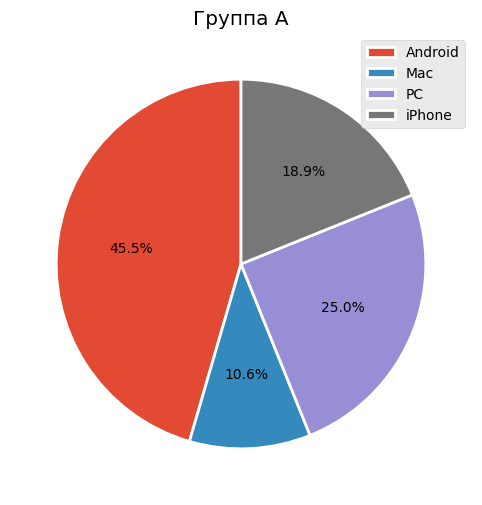

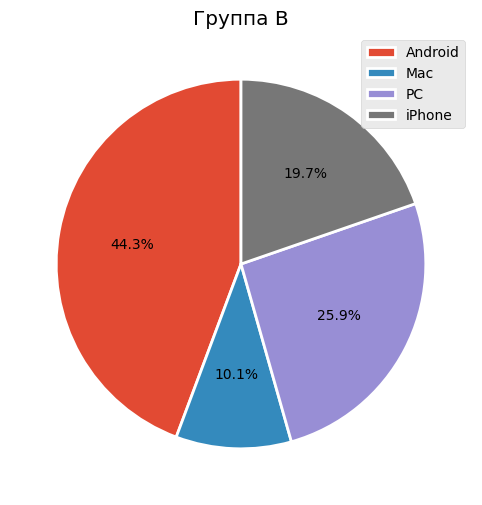

In [16]:
# Количество уникальных пользователей по группам и устройству
users_by_group_device = merged_good_df.groupby(["group", "device"])["user_id"].nunique()

# Доля каждого типа устройств в группе А и В
share_device = (
    (users_by_group_device / users_by_group_device.groupby("group").transform("sum"))
    .round(3)
    .reset_index()
)

# Визуализация распределения устройств внутри групп А и В
for group in share_device["group"].unique():
    subset = share_device[share_device["group"] == group]
    subset.plot(
        kind="pie",
        y="user_id",
        labels=subset["device"],
        ylabel="",
        legend=True,
        startangle=90,
        autopct="%1.1f%%",
        labeldistance=None,
        wedgeprops={"edgecolor": "white", "linewidth": 2},
        title=f"Группа {group}",
    )

    plt.show()

Контрольная и тестовая группы сходятся в распределении пользователей по устройствам. Это означает, что рандомизация прошла успешно.

### 2.5 Корректность размера выборки по выбранным параметрам

Оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,
- мощность теста — 80%,
- достоверность теста — 95%
- Предполагаемый MDE - 0.03

In [17]:
alpha = 0.05
beta = 0.2
power = 0.8
p = 0.3
mde = 0.03
effect_size = proportion_effectsize(p, p + mde)

power_analysis = NormalIndPower()

sample_size = power_analysis.solve_power(
    effect_size=effect_size, alpha=alpha, power=power, ratio=1
)

grp_a = merged_good_df[merged_good_df["group"] == "A"]["user_id"].nunique()
grp_b = merged_good_df[merged_good_df["group"] == "B"]["user_id"].nunique()

print(f"Требуемые размер выборки на одну группу: {sample_size}")
print(f"Уникальных пользователей в группе А = {grp_a}, в В = {grp_b}")

Требуемые размер выборки на одну группу: 3761.596974012117
Уникальных пользователей в группе А = 5277, в В = 5127


При заданных параметрах теста размеры выборки превышают требования. Это означает, что тест может набрать еще больше мощности и детектировать более меньший эффект, чем предполагается (3 п.п.) 

### 2.6 Расчет конверсии для групп

- Рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [18]:
# Кол-во уникальных пользователей, сделавших покупку
user_purchase = (
    merged_good_df[merged_good_df["event_name"] == "purchase"]
    .groupby("group")["user_id"]
    .nunique()
)

# Кол-во уникальных пользователей
all_users = merged_good_df.groupby("group")["user_id"].nunique()

# Расчет конверсии в покупку
conversion = round((user_purchase / all_users), 4)

print(
    f"Конверсия из регистрации в покупку в контрольной группе А = {conversion.values[0]}"
)
print(
    f"Конверсия из регистрации в покупку в тестовой группе B = {conversion.values[1]}"
)
print(
    f"Относительная разница между группами = {round(abs(conversion.values[1]-conversion.values[0]) / conversion.values[0] * 100, 4)}%"
)
print(
    f"Абсолютная разница между группами = {round((conversion.values[1]-conversion.values[0]) * 100, 4)} п.п."
)

Конверсия из регистрации в покупку в контрольной группе А = 0.2755
Конверсия из регистрации в покупку в тестовой группе B = 0.2928
Относительная разница между группами = 6.2795%
Абсолютная разница между группами = 1.73 п.п.


- Предварительно, между тестовой B и контрольной А группами есть различия, **конверсия в тестовой группе В выше на 6.27%** относительно контрольной группы А. Абсолютный прирост конверсии в группе В +1.73 п.п., **предполагаемый прирост в 3 п.п. не достигнут.**

## 3. Проверка статистической значимости результатов A/B-тестирования

- Для проверки статистической значимости различия конверсии между группами используем z-тест пропорций, так как конверсия - это долевая метрика. 

In [19]:
# Размеры выборок групп
n_a, n_b = all_users.values[0], all_users.values[1]

# Доля успехов (успешных первых сессий) в группах
m_a, m_b = user_purchase.values[0], user_purchase.values[1]

# Доля успехов в группах
p_a, p_b = m_a / n_a, m_b / n_b

print(f"Размер выборки группы А = {n_a}, B = {n_b}")
print(f"Количество успехов (успешных сессий) группы А = {m_a}, B = {m_b}")
print(f"Доля успехов группы А = {p_a}, B = {p_b}")

# Проверка предпосылки о достаточном количестве данных в выборках
if (
    (p_a * n_a > 10)
    and ((1 - p_a) * n_a > 10)
    and (p_b * n_b > 10)
    and ((1 - p_b) * n_b > 10)
):
    print("Предпосылка о достаточном количестве данных выполняется")
else:
    print("Предпосылка о достаточном количестве данных НЕ выполняется")

Размер выборки группы А = 5277, B = 5127
Количество успехов (успешных сессий) группы А = 1454, B = 1501
Доля успехов группы А = 0.2755353420504074, B = 0.29276379949288084
Предпосылка о достаточном количестве данных выполняется


In [20]:
z_stat, pvalue = proportions_ztest([m_b, m_a], [n_b, n_a], alternative="larger")

print(f"pvalue = {pvalue}")

if pvalue >= alpha:
    print(
        f"Недостаточно оснований отклонить нулевую гипотезу. Разница между группами статистически не значима"
    )
else:
    print(
        f"Альтернативная гипотеза находит подтверждение. Разница между группами статистически значима и утверждать, что конверсия в группе B выше, чем в группе А, статистически верно"
    )

pvalue = 0.02569270074635989
Альтернативная гипотеза находит подтверждение. Разница между группами статистически значима и утверждать, что конверсия в группе B выше, чем в группе А, статистически верно


## 4. Интерпретация результатов

**Предварительные результаты расчета конверсии:**

- Конверсия из регистрации в покупку в контрольной группе А = 0.2755
- Конверсия из регистрации в покупку в тестовой группе B = 0.2928
- Относительная разница между группами = 6.2795%
- Абсолютная разница между группами = 1.73 п.п. (реальный $MDE$)

**Результаты и интерпретация статистической проверки результатов:**

- После проведения одностороннего статистического теста z-тест пропорций мы получили **pvalue = 0.02 < alpha 0.05**. Это означает, что наша односторонняя **альтернативная гипотеза находит подтвеждение** ($pA < pB$), конверсия в тестовой группе B с новым интерфейсом выше на 1.73 п.п., чем в контрольной группе A cо старым интерфейсом, и это утверждение статистически верно.

- Однако, **реальный $MDE$ (1.73 п.п.) оказался меньше, чем предполагаемый $MDE$ (3 п.п.)**. Меньший $MDE$ удалось детектировать, так как изначально мы набрали больше пользователей, чем требовалось.

- **В действительности не получится однозначно сказать, что изменение интерфейса можно выкатывать на всех пользователей**. С одной стороны, конверсия показала статистически значимый рост +1.73 п.п. в группе с новым интерфейсом, но практическая значимость для бизнеса не оправдана, так как предполагался эффект +3 п.п.. Возможно такой рост не оправдает затраты на разработку и внедрение.